# Inference Exchange — Depth of Market & Exchange Analytics

**What this notebook does**: takes the raw data from the market\_analysis notebook
and builds the actual exchange-grade visualizations that would power IE's UI —
depth-of-market (DOM) ladders, three-tier pricing breakdowns, simulated volume
profiles, price history, and cache economics.

**Data sources**:
1. OpenRouter public API — live model pricing (the supply side)
2. IE's static reference prices — direct-API provider prices
3. IE's transaction schema — simulated demand/volume data (since we don't have
   a live exchange yet, we synthesize realistic trading activity)

**What IE shows that OR doesn't**:
- Three-tier pricing (input / cache / output) instead of just output price
- Cache economics — what cache hits actually save consumers
- Provider-level offer stacks (DOM) per model
- Volume-at-price profiles
- Trust/encryption as a pricing dimension


In [1]:
import httpx, time, json, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
from datetime import datetime, timedelta

plt.rcParams.update({
    "figure.facecolor": "#0e0e0e",
    "axes.facecolor":   "#141414",
    "axes.edgecolor":   "#333",
    "axes.labelcolor":  "#ccc",
    "text.color":       "#ccc",
    "xtick.color":      "#999",
    "ytick.color":      "#999",
    "grid.color":       "#222",
    "legend.facecolor": "#1a1a1a",
    "legend.edgecolor": "#333",
    "figure.dpi":       120,
})

# IE's palette
C_RED    = "#ef4444"   # demand / consumer
C_GREEN  = "#22c55e"   # supply / provider
C_CYAN   = "#22d3ee"   # exchange / coordination
C_PURPLE = "#a78bfa"   # cache / savings
C_ORANGE = "#f97316"   # active / processing
C_GOLD   = "#eab308"   # value / settlement
C_BLUE   = "#3b82f6"   # trust / evidence


## 1 — Fetch live supply data

In [2]:
print("Fetching OpenRouter model catalog...")
resp = httpx.get("https://openrouter.ai/api/v1/models", timeout=30)
or_raw = resp.json()["data"]

rows = []
for m in or_raw:
    p = m.get("pricing", {})
    inp = float(p.get("prompt", "0") or "0")
    out = float(p.get("completion", "0") or "0")
    if inp <= 0 and out <= 0:
        continue
    rows.append({
        "source": "openrouter",
        "model_id": m["id"],
        "vendor": m["id"].split("/")[0].strip("~"),
        "name": m.get("name", m["id"]),
        "input_mtok": round(inp * 1_000_000, 4),
        "output_mtok": round(out * 1_000_000, 4),
        "context": m.get("context_length", 0),
    })

or_df = pd.DataFrame(rows)
print(f"  {len(or_df)} priced models from {or_df['vendor'].nunique()} vendors")

# Identify the top 8 most-demanded model families for deep analysis
def classify_family(row):
    mid = (row["model_id"] + " " + row["name"]).lower()
    if "claude" in mid and "sonnet" in mid: return "Claude Sonnet"
    if "claude" in mid and "opus" in mid: return "Claude Opus"
    if "claude" in mid and "haiku" in mid: return "Claude Haiku"
    if "gpt-4o" in mid and "mini" in mid: return "GPT-4o Mini"
    if "gpt-4o" in mid: return "GPT-4o"
    if "gpt-4.1" in mid: return "GPT-4.1"
    if "gpt-5" in mid: return "GPT-5"
    if "gemini" in mid and "flash" in mid: return "Gemini Flash"
    if "gemini" in mid and "pro" in mid: return "Gemini Pro"
    if "deepseek" in mid and ("r1" in mid or "reason" in mid): return "DeepSeek R1"
    if "deepseek" in mid: return "DeepSeek V3/V4"
    if "llama" in mid and "70b" in mid: return "Llama 70B"
    if "llama" in mid and "8b" in mid: return "Llama 8B"
    if "qwen" in mid and "72b" in mid: return "Qwen 72B"
    if "qwen" in mid: return "Qwen (other)"
    if "mistral" in mid and "large" in mid: return "Mistral Large"
    return None

or_df["family"] = or_df.apply(classify_family, axis=1)
top_families = or_df[or_df["family"].notna()]["family"].value_counts().head(10)
print(f"\nTop model families (by variant count on OR):")
print(top_families.to_string())


Fetching OpenRouter model catalog...


  438 priced models from 52 vendors

Top model families (by variant count on OR):
family
Qwen (other)      51
GPT-5             47
Gemini Flash      24
DeepSeek V3/V4    16
Claude Opus       15
Claude Sonnet     10
Gemini Pro         9
GPT-4.1            6
Llama 70B          5
GPT-4o             5


## 2 — Three-tier pricing: input / cache / output

OpenRouter shows a single price per model.  IE exposes **three tiers** because
real inference costs vary dramatically based on how you use the model:

- **Input price**: cost of fresh prompt tokens
- **Cache price**: cost of cached prompt tokens (KV-cache hits) — typically 50-90% cheaper
- **Output price**: cost of generated tokens — usually the most expensive

This is the pricing dimension that makes IE a real exchange vs. a price comparison
site.  For a workload with 80% cache hits, the effective input cost drops massively.


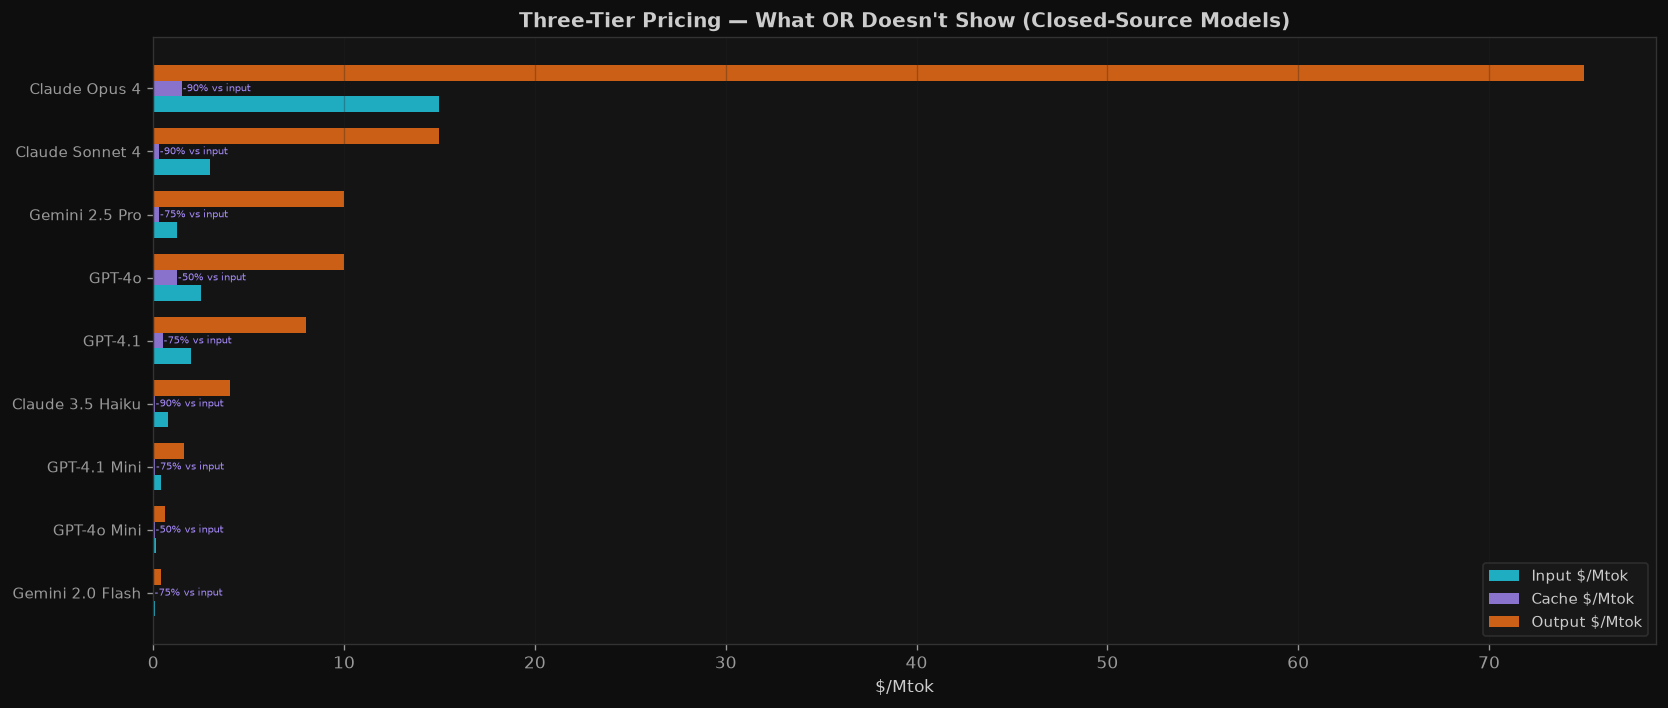


Cache discount vs input price:
  GPT-4o Mini           input=$0.15  cache=$0.075  discount=50%
  GPT-4o                input=$2.50  cache=$1.250  discount=50%
  GPT-4.1 Mini          input=$0.40  cache=$0.100  discount=75%
  GPT-4.1               input=$2.00  cache=$0.500  discount=75%
  Claude 3.5 Haiku      input=$0.80  cache=$0.080  discount=90%
  Claude Sonnet 4       input=$3.00  cache=$0.300  discount=90%
  Claude Opus 4         input=$15.00  cache=$1.500  discount=90%
  Gemini 2.0 Flash      input=$0.10  cache=$0.025  discount=75%
  Gemini 2.5 Pro        input=$1.25  cache=$0.312  discount=75%
  DeepSeek V3           input=$0.27  cache=$0.070  discount=74%
  DeepSeek R1           input=$0.55  cache=$0.140  discount=75%


In [3]:
# IE's static three-tier prices from price_collector.py
tiers = [
    # name, input, cache, output, source, comparison_type
    ("GPT-4o Mini",       0.15,  0.075, 0.60,  "openai",    "closed"),
    ("GPT-4o",            2.50,  1.25,  10.00, "openai",    "closed"),
    ("GPT-4.1 Mini",      0.40,  0.10,  1.60,  "openai",    "closed"),
    ("GPT-4.1",           2.00,  0.50,  8.00,  "openai",    "closed"),
    ("Claude 3.5 Haiku",  0.80,  0.08,  4.00,  "anthropic", "closed"),
    ("Claude Sonnet 4",   3.00,  0.30,  15.00, "anthropic", "closed"),
    ("Claude Opus 4",     15.00, 1.50,  75.00, "anthropic", "closed"),
    ("Gemini 2.0 Flash",  0.10,  0.025, 0.40,  "google",    "closed"),
    ("Gemini 2.5 Pro",    1.25,  0.3125,10.00, "google",    "closed"),
    ("DeepSeek V3",       0.27,  0.07,  1.10,  "deepseek",  "open"),
    ("DeepSeek R1",       0.55,  0.14,  2.19,  "deepseek",  "open"),
    ("Llama 3.1 8B (DI)", 0.06,  0.0,   0.06,  "deepinfra", "open"),
    ("Llama 3.1 70B (DI)",0.35,  0.0,   0.40,  "deepinfra", "open"),
    ("Llama 3.1 8B (Groq)",0.05, 0.0,   0.08,  "groq",      "open"),
    ("Llama 3.1 8B (FW)", 0.10,  0.0,   0.10,  "fireworks", "open"),
    ("Llama 3.1 8B (TG)", 0.18,  0.0,   0.18,  "together",  "open"),
]

tier_df = pd.DataFrame(tiers, columns=["model", "input", "cache", "output", "source", "type"])
tier_df["cache_discount_pct"] = ((1 - tier_df["cache"] / tier_df["input"]) * 100).round(0)
tier_df.loc[tier_df["cache"] == 0, "cache_discount_pct"] = 0  # no cache pricing = no discount

# Plot three-tier breakdown for closed-source models
closed = tier_df[tier_df["type"] == "closed"].sort_values("output", ascending=True)

fig, ax = plt.subplots(figsize=(14, 6))
y = np.arange(len(closed))
h = 0.25

bars_in  = ax.barh(y - h, closed["input"],  height=h, color=C_CYAN,   alpha=0.8, label="Input $/Mtok")
bars_ca  = ax.barh(y,     closed["cache"],   height=h, color=C_PURPLE, alpha=0.8, label="Cache $/Mtok")
bars_out = ax.barh(y + h, closed["output"],  height=h, color=C_ORANGE, alpha=0.8, label="Output $/Mtok")

ax.set_yticks(y)
ax.set_yticklabels(closed["model"], fontsize=9)
ax.set_xlabel("$/Mtok")
ax.set_title("Three-Tier Pricing — What OR Doesn't Show (Closed-Source Models)",
             fontsize=12, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, axis="x", alpha=0.3)

# Annotate cache discounts
for j, (_, row) in enumerate(closed.iterrows()):
    if row["cache_discount_pct"] > 0:
        ax.text(row["cache"] + 0.05, j, f"-{row['cache_discount_pct']:.0f}% vs input",
                fontsize=6, va="center", color=C_PURPLE)

plt.tight_layout()
plt.show()

print("\nCache discount vs input price:")
for _, r in tier_df[tier_df["cache_discount_pct"] > 0].iterrows():
    print(f"  {r['model']:20s}  input=${r['input']:.2f}  cache=${r['cache']:.3f}  discount={r['cache_discount_pct']:.0f}%")


## 3 — Cache economics: what cache hits actually save

For a real workload, the cache hit rate determines the *effective* input cost.
This is one of IE's key advantages — showing consumers what they actually pay,
not just the headline price.

We simulate different cache hit rates and show the effective blended cost.


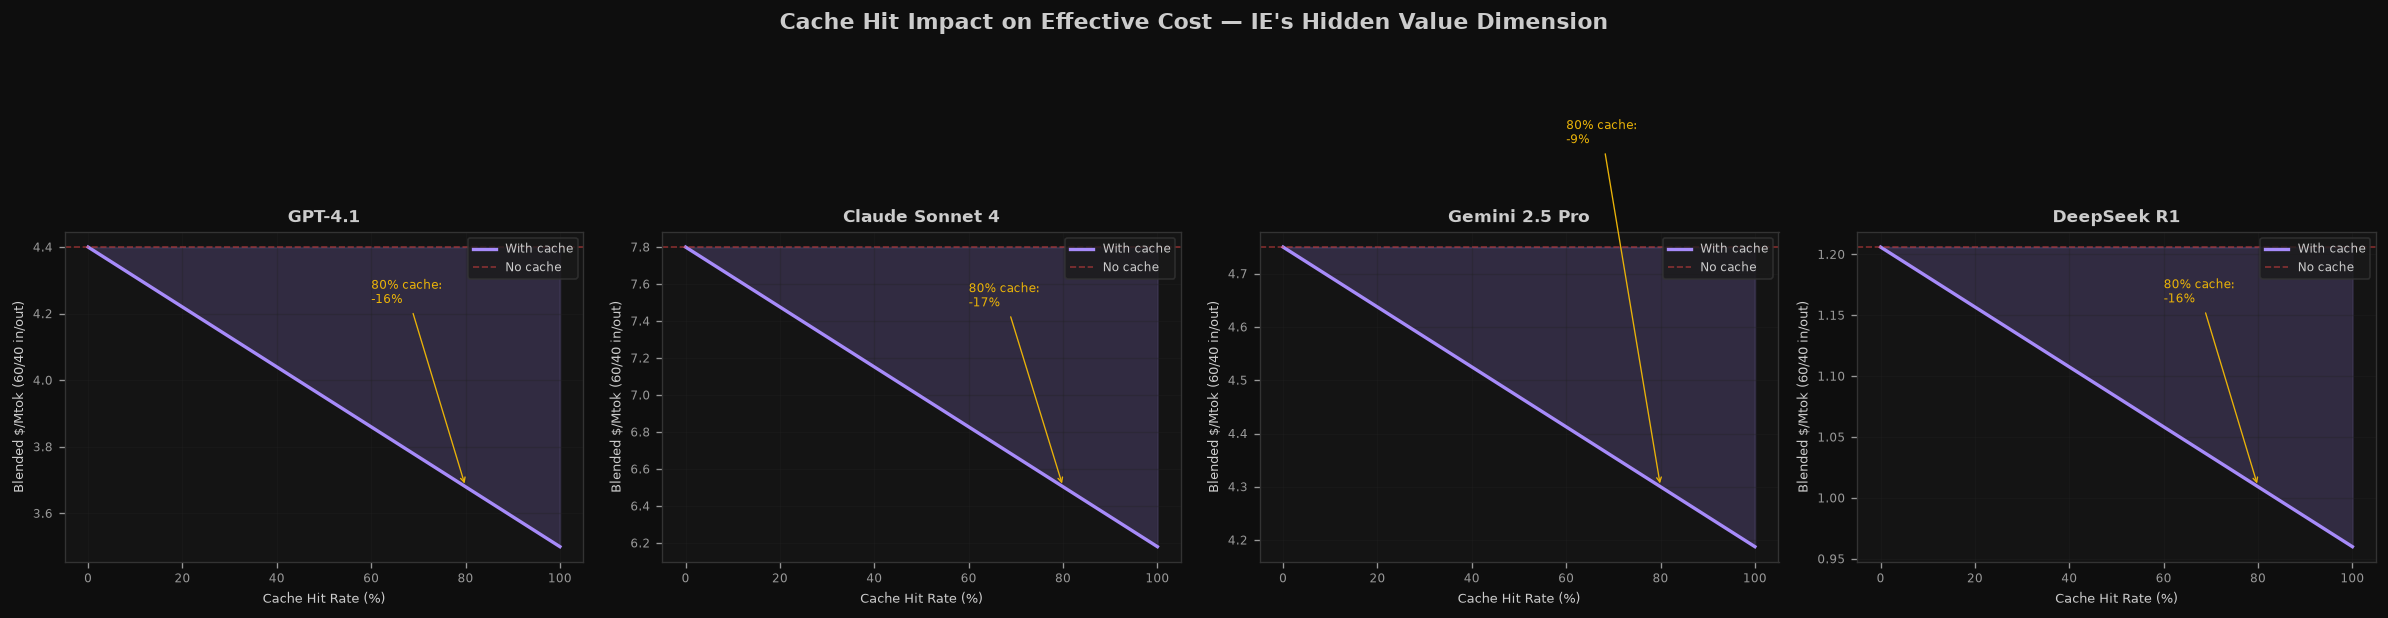

In [4]:
models_for_cache = [
    ("GPT-4.1",         2.00, 0.50, 8.00),
    ("Claude Sonnet 4", 3.00, 0.30, 15.00),
    ("Gemini 2.5 Pro",  1.25, 0.3125, 10.00),
    ("DeepSeek R1",     0.55, 0.14, 2.19),
]

cache_rates = np.arange(0, 1.01, 0.05)

fig, axes = plt.subplots(1, len(models_for_cache), figsize=(5 * len(models_for_cache), 5), squeeze=False)
axes = axes.flatten()

for i, (name, inp, cache, out) in enumerate(models_for_cache):
    ax = axes[i]
    effective_input = inp * (1 - cache_rates) + cache * cache_rates
    # Simulate a typical workload: 60% input, 40% output tokens
    total_cost = 0.6 * effective_input + 0.4 * out
    no_cache_cost = 0.6 * inp + 0.4 * out

    savings_pct = (1 - total_cost / no_cache_cost) * 100

    ax.fill_between(cache_rates * 100, total_cost, no_cache_cost, alpha=0.2, color=C_PURPLE)
    ax.plot(cache_rates * 100, total_cost, color=C_PURPLE, linewidth=2, label="With cache")
    ax.axhline(no_cache_cost, color=C_RED, linestyle="--", alpha=0.5, linewidth=1, label="No cache")
    ax.set_xlabel("Cache Hit Rate (%)", fontsize=8)
    ax.set_ylabel("Blended $/Mtok (60/40 in/out)", fontsize=8)
    ax.set_title(f"{name}", fontsize=10, fontweight="bold")
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=7)

    # Annotate savings at 80% cache
    idx_80 = int(0.8 / 0.05)
    ax.annotate(f"80% cache:\n-{savings_pct[idx_80]:.0f}%",
                xy=(80, total_cost[idx_80]), fontsize=7, color=C_GOLD,
                xytext=(60, total_cost[idx_80] * 1.15),
                arrowprops=dict(arrowstyle="->", color=C_GOLD, lw=0.8))

fig.suptitle("Cache Hit Impact on Effective Cost — IE's Hidden Value Dimension",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 4 — Depth of Market: the order book ladder

This is the core exchange visualization.  For each popular model family, show
every available "offer" as a row in a price ladder — sorted from cheapest to
most expensive — with provider, price, estimated capacity, and trust level.

This is what IE's Exchange page should look like: not a flat model list, but
a price-ranked offer book.


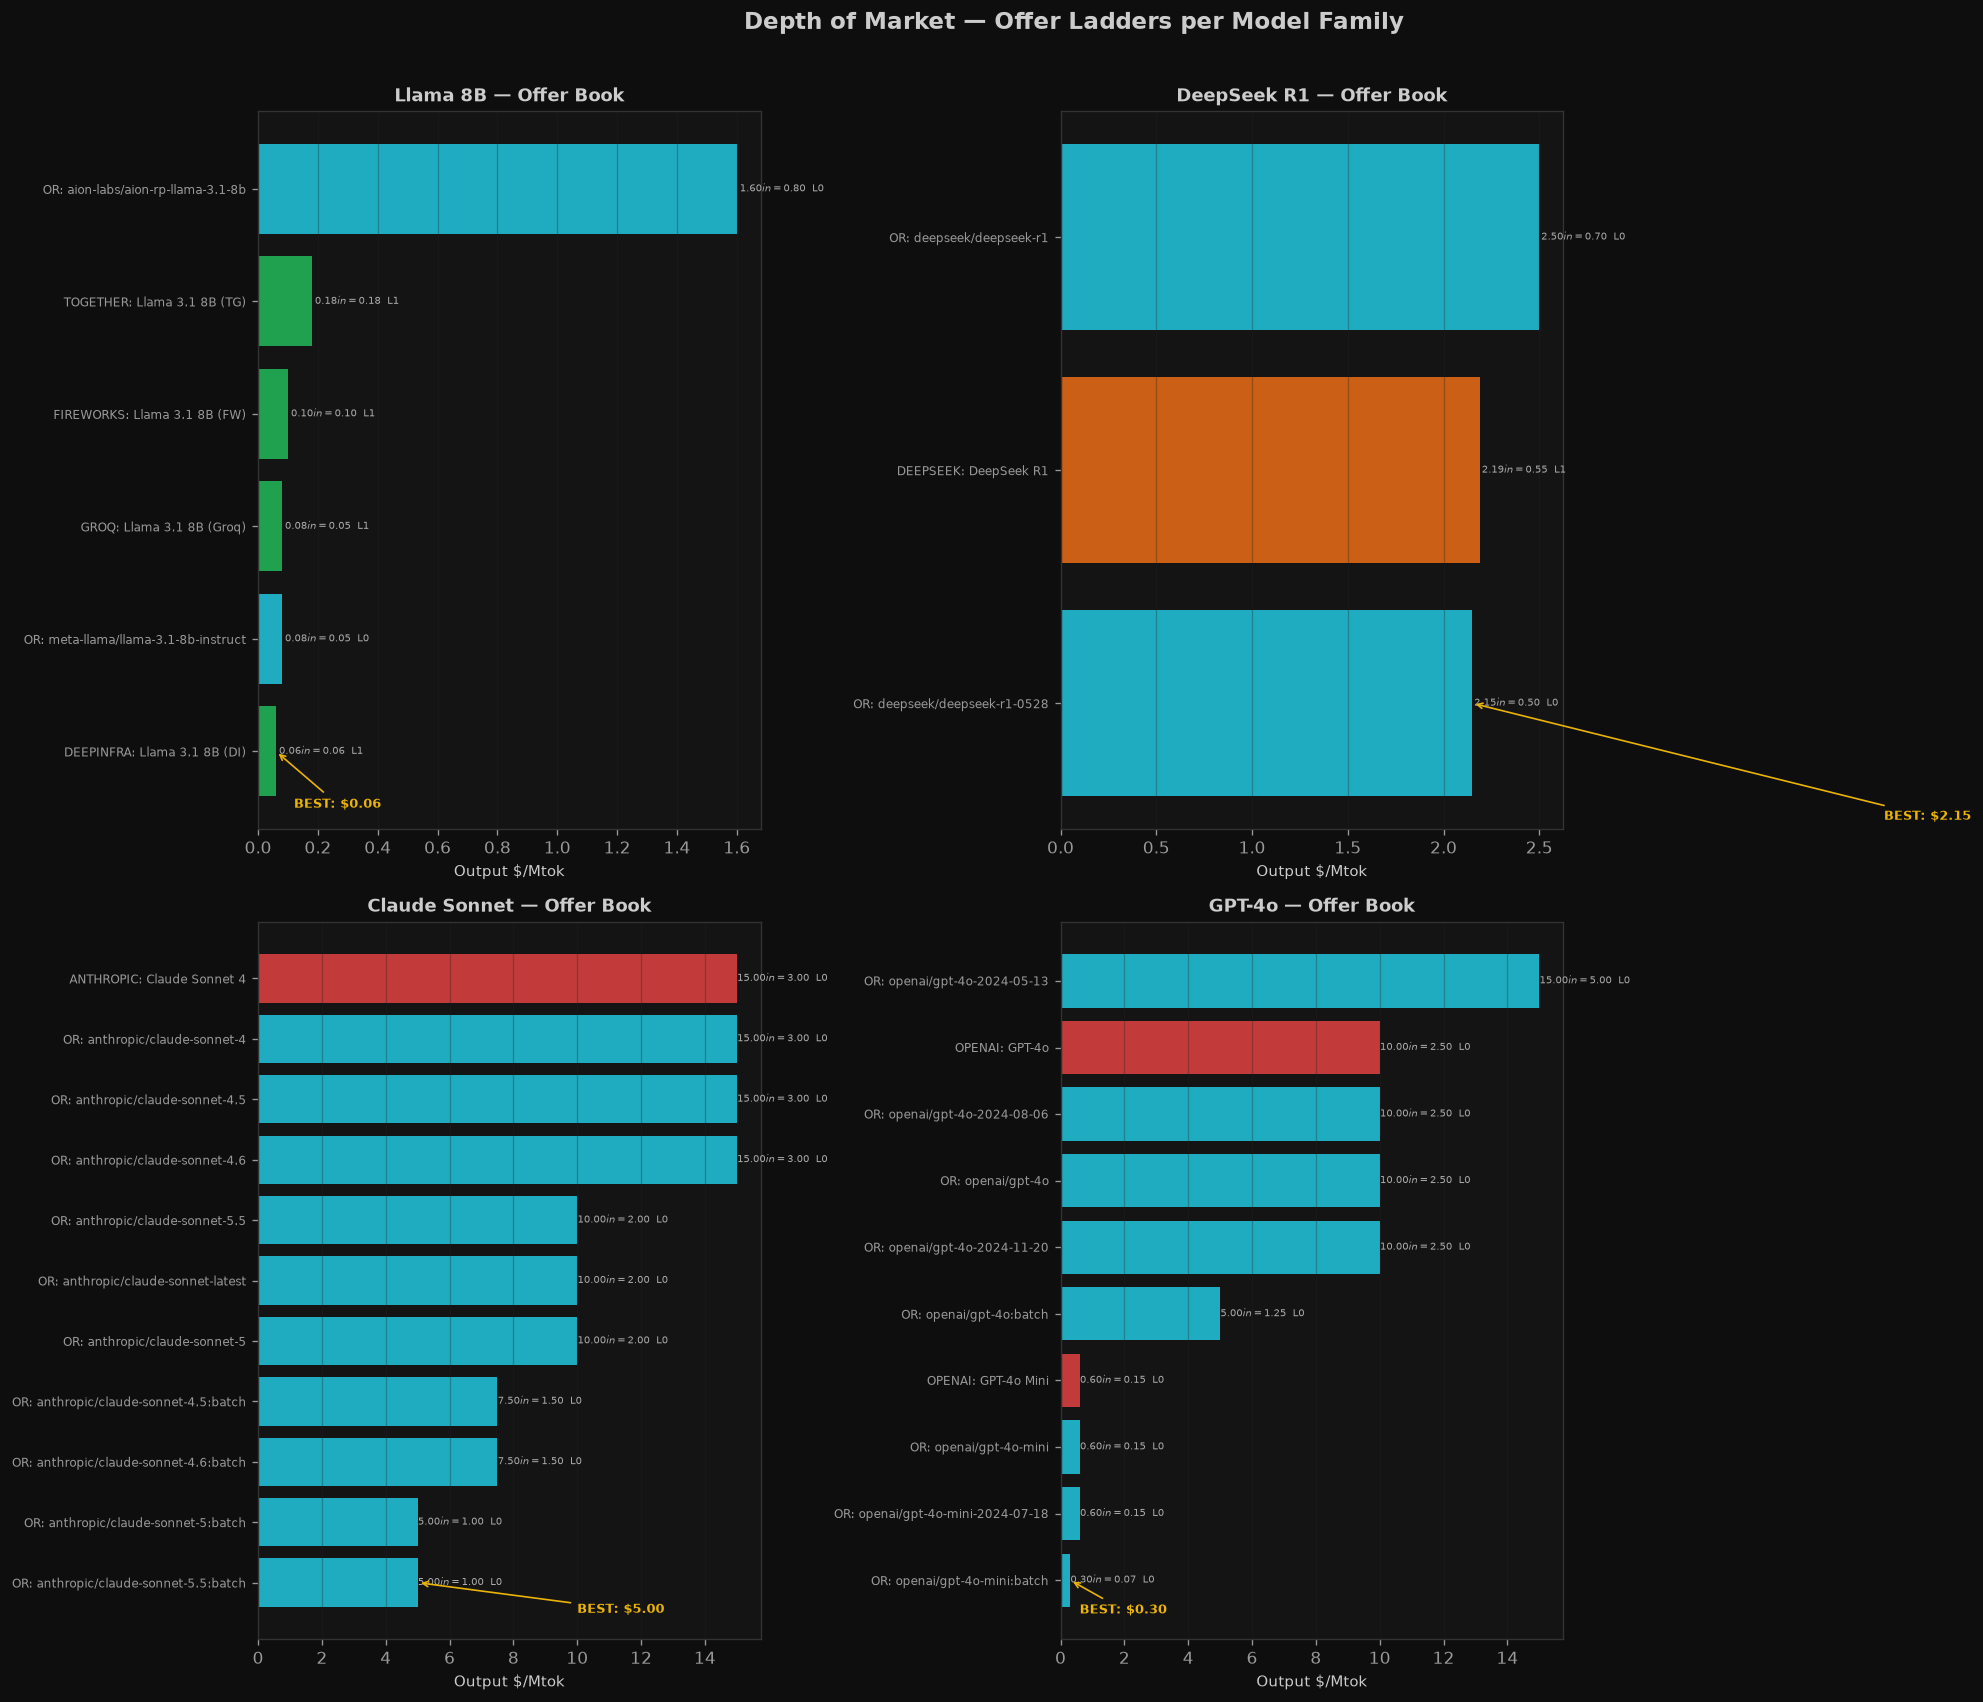

In [5]:
# Build a DOM for the top model families by combining OR data + static prices
# We pick a few representative families and merge all offers

dom_families = {
    "Llama 8B": {
        "or_kw": ["llama", "8b"],
        "static_kw": ["Llama 3.1 8B"],
    },
    "DeepSeek R1": {
        "or_kw": ["deepseek", "r1"],
        "static_kw": ["DeepSeek R1"],
    },
    "Claude Sonnet": {
        "or_kw": ["claude", "sonnet"],
        "static_kw": ["Claude Sonnet"],
    },
    "GPT-4o": {
        "or_kw": ["gpt-4o"],
        "static_kw": ["GPT-4o"],
    },
}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, (fam_name, config) in enumerate(dom_families.items()):
    ax = axes[idx]
    offers = []

    # OpenRouter offers
    for _, row in or_df.iterrows():
        mid = row["model_id"].lower()
        if all(kw in mid for kw in config["or_kw"]):
            offers.append({
                "provider": f"OR: {row['vendor']}/{row['model_id'].split('/')[-1][:25]}",
                "output": row["output_mtok"],
                "input": row["input_mtok"],
                "source": "openrouter",
                "trust": "L0",  # OR doesn't expose trust
                "slots": "∞",
            })

    # Static direct-API offers
    for _, row in tier_df.iterrows():
        if any(kw in row["model"] for kw in config["static_kw"]):
            offers.append({
                "provider": f"{row['source'].upper()}: {row['model']}",
                "output": row["output"],
                "input": row["input"],
                "source": row["source"],
                "trust": "L1" if row["type"] == "open" else "L0",
                "slots": "—",
            })

    if not offers:
        ax.text(0.5, 0.5, f"No offers for {fam_name}", transform=ax.transAxes,
                ha="center", va="center", fontsize=11, color="#666")
        ax.set_title(fam_name, fontsize=12, fontweight="bold")
        continue

    odf = pd.DataFrame(offers).sort_values("output").head(15)

    # Color by source type
    colors = []
    for _, r in odf.iterrows():
        if r["source"] == "openrouter": colors.append(C_CYAN)
        elif r["source"] in ("deepinfra","groq","fireworks","together"): colors.append(C_GREEN)
        elif r["source"] in ("openai","anthropic","google"): colors.append(C_RED)
        else: colors.append(C_ORANGE)

    bars = ax.barh(range(len(odf)), odf["output"], color=colors, alpha=0.8)
    ax.set_yticks(range(len(odf)))
    ax.set_yticklabels(odf["provider"], fontsize=7)
    ax.set_xlabel("Output $/Mtok", fontsize=9)
    ax.set_title(f"{fam_name} — Offer Book", fontsize=11, fontweight="bold")
    ax.grid(True, axis="x", alpha=0.3)

    for j, (_, r) in enumerate(odf.iterrows()):
        ax.text(r["output"] + 0.01, j,
                f"${r['output']:.2f}  in=${r['input']:.2f}  {r['trust']}",
                fontsize=6, va="center", color="#aaa")

    # Best ask annotation
    best = odf.iloc[0]
    ax.annotate(f"BEST: ${best['output']:.2f}", xy=(best["output"], 0),
                fontsize=8, color=C_GOLD, fontweight="bold",
                xytext=(best["output"] * 2, -0.5),
                arrowprops=dict(arrowstyle="->", color=C_GOLD))

fig.suptitle("Depth of Market — Offer Ladders per Model Family",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 5 — Volume profile: where does demand concentrate?

We don't have live IE transaction data yet, so we synthesize a realistic demand
distribution based on what we know about the inference market:

- Most volume concentrates on 5-10 popular models
- Demand follows a power-law (top models get 10-50x more requests)
- Price sensitivity creates natural volume-at-price bands

This is the "volume profile" that financial exchanges show — what price levels
have the most activity, and where are the gaps.


Simulated 10000 requests over 7 days
Unique models: 12
Total tokens: 4,981,959 output, 10,895,211 input
Mean cache rate: 39.6%


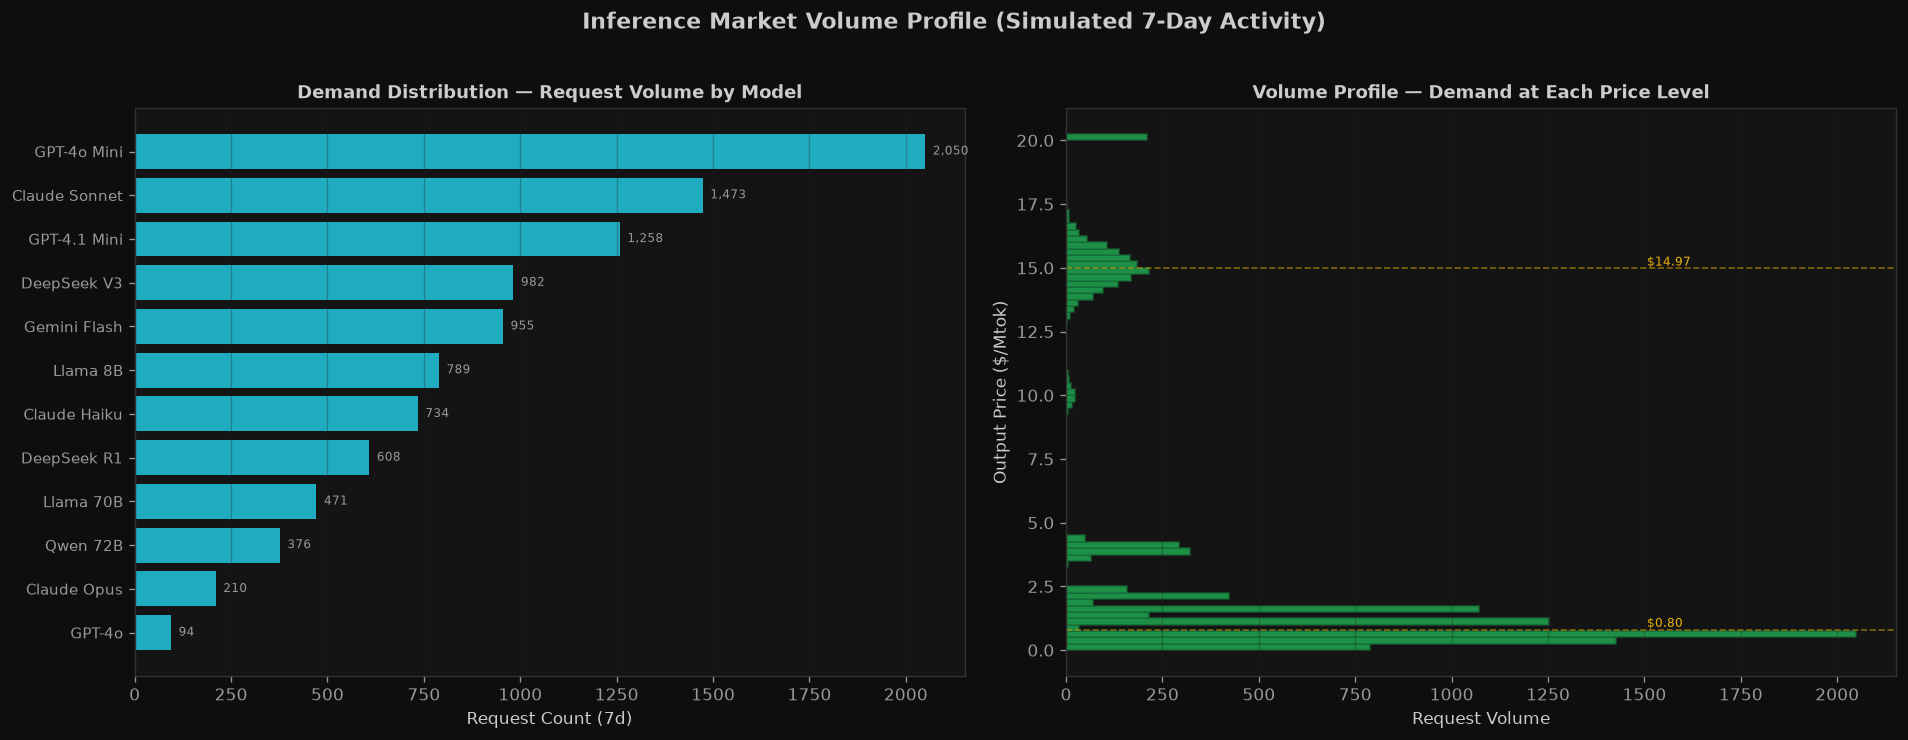

In [6]:
np.random.seed(42)

# Simulate 10K requests over 7 days across popular models
n_requests = 10_000
model_weights = {
    "GPT-4o Mini":     0.20,
    "Claude Sonnet":   0.15,
    "GPT-4.1 Mini":    0.12,
    "Gemini Flash":    0.10,
    "DeepSeek V3":     0.10,
    "Llama 8B":        0.08,
    "Claude Haiku":    0.07,
    "DeepSeek R1":     0.06,
    "Llama 70B":       0.05,
    "Qwen 72B":        0.04,
    "Claude Opus":     0.02,
    "GPT-4o":          0.01,
}

# Base output prices for simulation
model_prices = {
    "GPT-4o Mini": 0.60, "Claude Sonnet": 15.00, "GPT-4.1 Mini": 1.60,
    "Gemini Flash": 0.40, "DeepSeek V3": 1.10, "Llama 8B": 0.08,
    "Claude Haiku": 4.00, "DeepSeek R1": 2.19, "Llama 70B": 0.40,
    "Qwen 72B": 1.20, "Claude Opus": 75.00, "GPT-4o": 10.00,
}

models = list(model_weights.keys())
weights = list(model_weights.values())

sim_data = []
base_time = time.time() - 7 * 86400  # 7 days ago

for i in range(n_requests):
    model = np.random.choice(models, p=weights)
    base_price = model_prices[model]
    # Add price noise (±10% — different providers)
    actual_price = base_price * (1 + np.random.normal(0, 0.05))
    # Token counts: power-law distributed
    output_tokens = int(np.random.lognormal(5.5, 1.2))  # median ~245 tokens
    input_tokens = int(np.random.lognormal(6.5, 1.0))   # median ~665 tokens
    cached_tokens = int(input_tokens * np.random.beta(2, 3))  # skewed toward lower cache
    latency_ms = int(np.random.lognormal(7, 0.5))  # median ~1100ms
    tps = max(5, np.random.normal(80, 30))

    sim_data.append({
        "model": model,
        "output_price": round(actual_price, 4),
        "output_tokens": output_tokens,
        "input_tokens": input_tokens,
        "cached_tokens": cached_tokens,
        "cache_rate": round(cached_tokens / max(input_tokens, 1), 3),
        "cost_usd": round(output_tokens / 1e6 * actual_price + input_tokens / 1e6 * base_price * 0.3, 6),
        "latency_ms": latency_ms,
        "tps": round(tps, 1),
        "timestamp": base_time + i * (7 * 86400 / n_requests) + np.random.normal(0, 300),
    })

sim_df = pd.DataFrame(sim_data)
sim_df["hour"] = pd.to_datetime(sim_df["timestamp"], unit="s").dt.floor("h")
sim_df["day"] = pd.to_datetime(sim_df["timestamp"], unit="s").dt.date

print(f"Simulated {len(sim_df)} requests over 7 days")
print(f"Unique models: {sim_df['model'].nunique()}")
print(f"Total tokens: {sim_df['output_tokens'].sum():,} output, {sim_df['input_tokens'].sum():,} input")
print(f"Mean cache rate: {sim_df['cache_rate'].mean():.1%}")

# Volume profile: requests per model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: request volume by model
vol = sim_df["model"].value_counts()
ax1.barh(range(len(vol)), vol.values, color=C_CYAN, alpha=0.8)
ax1.set_yticks(range(len(vol)))
ax1.set_yticklabels(vol.index, fontsize=9)
ax1.set_xlabel("Request Count (7d)")
ax1.set_title("Demand Distribution — Request Volume by Model", fontsize=11, fontweight="bold")
ax1.grid(True, axis="x", alpha=0.3)
ax1.invert_yaxis()

for j, v in enumerate(vol.values):
    ax1.text(v + 20, j, f"{v:,}", fontsize=7, va="center", color="#999")

# Right: volume-at-price (output $/Mtok)
prices_all = sim_df["output_price"].clip(upper=20)
bins = np.arange(0, 20.5, 0.25)
ax2.hist(prices_all, bins=bins, orientation="horizontal", color=C_GREEN, alpha=0.7, edgecolor="#166534")
ax2.set_ylabel("Output Price ($/Mtok)")
ax2.set_xlabel("Request Volume")
ax2.set_title("Volume Profile — Demand at Each Price Level", fontsize=11, fontweight="bold")
ax2.grid(True, axis="x", alpha=0.3)

# Mark high-volume price levels
from scipy import stats as _stats  # noqa: E402 (only used here)
try:
    kde = _stats.gaussian_kde(prices_all.dropna())
    x_kde = np.linspace(0, 20, 200)
    y_kde = kde(x_kde)
    # Find modes (peaks)
    from scipy.signal import find_peaks
    peaks, _ = find_peaks(y_kde, height=0.01, distance=10)
    for pk in peaks[:5]:
        ax2.axhline(x_kde[pk], color=C_GOLD, linestyle="--", alpha=0.5, linewidth=1)
        ax2.text(ax2.get_xlim()[1] * 0.7, x_kde[pk], f"${x_kde[pk]:.2f}",
                 fontsize=7, color=C_GOLD, va="bottom")
except Exception:
    pass  # scipy optional

fig.suptitle("Inference Market Volume Profile (Simulated 7-Day Activity)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 6 — Price over time: reference price history

IE's `price_collector.py` snapshots reference prices to SQLite every 30 minutes.
Since the exchange is new, we simulate what a 30-day price history looks like
for popular models — with the kind of price movements that actually happen
(provider launches, price cuts, competitive pressure).

This is the candlestick/line chart that belongs on the Exchange page.


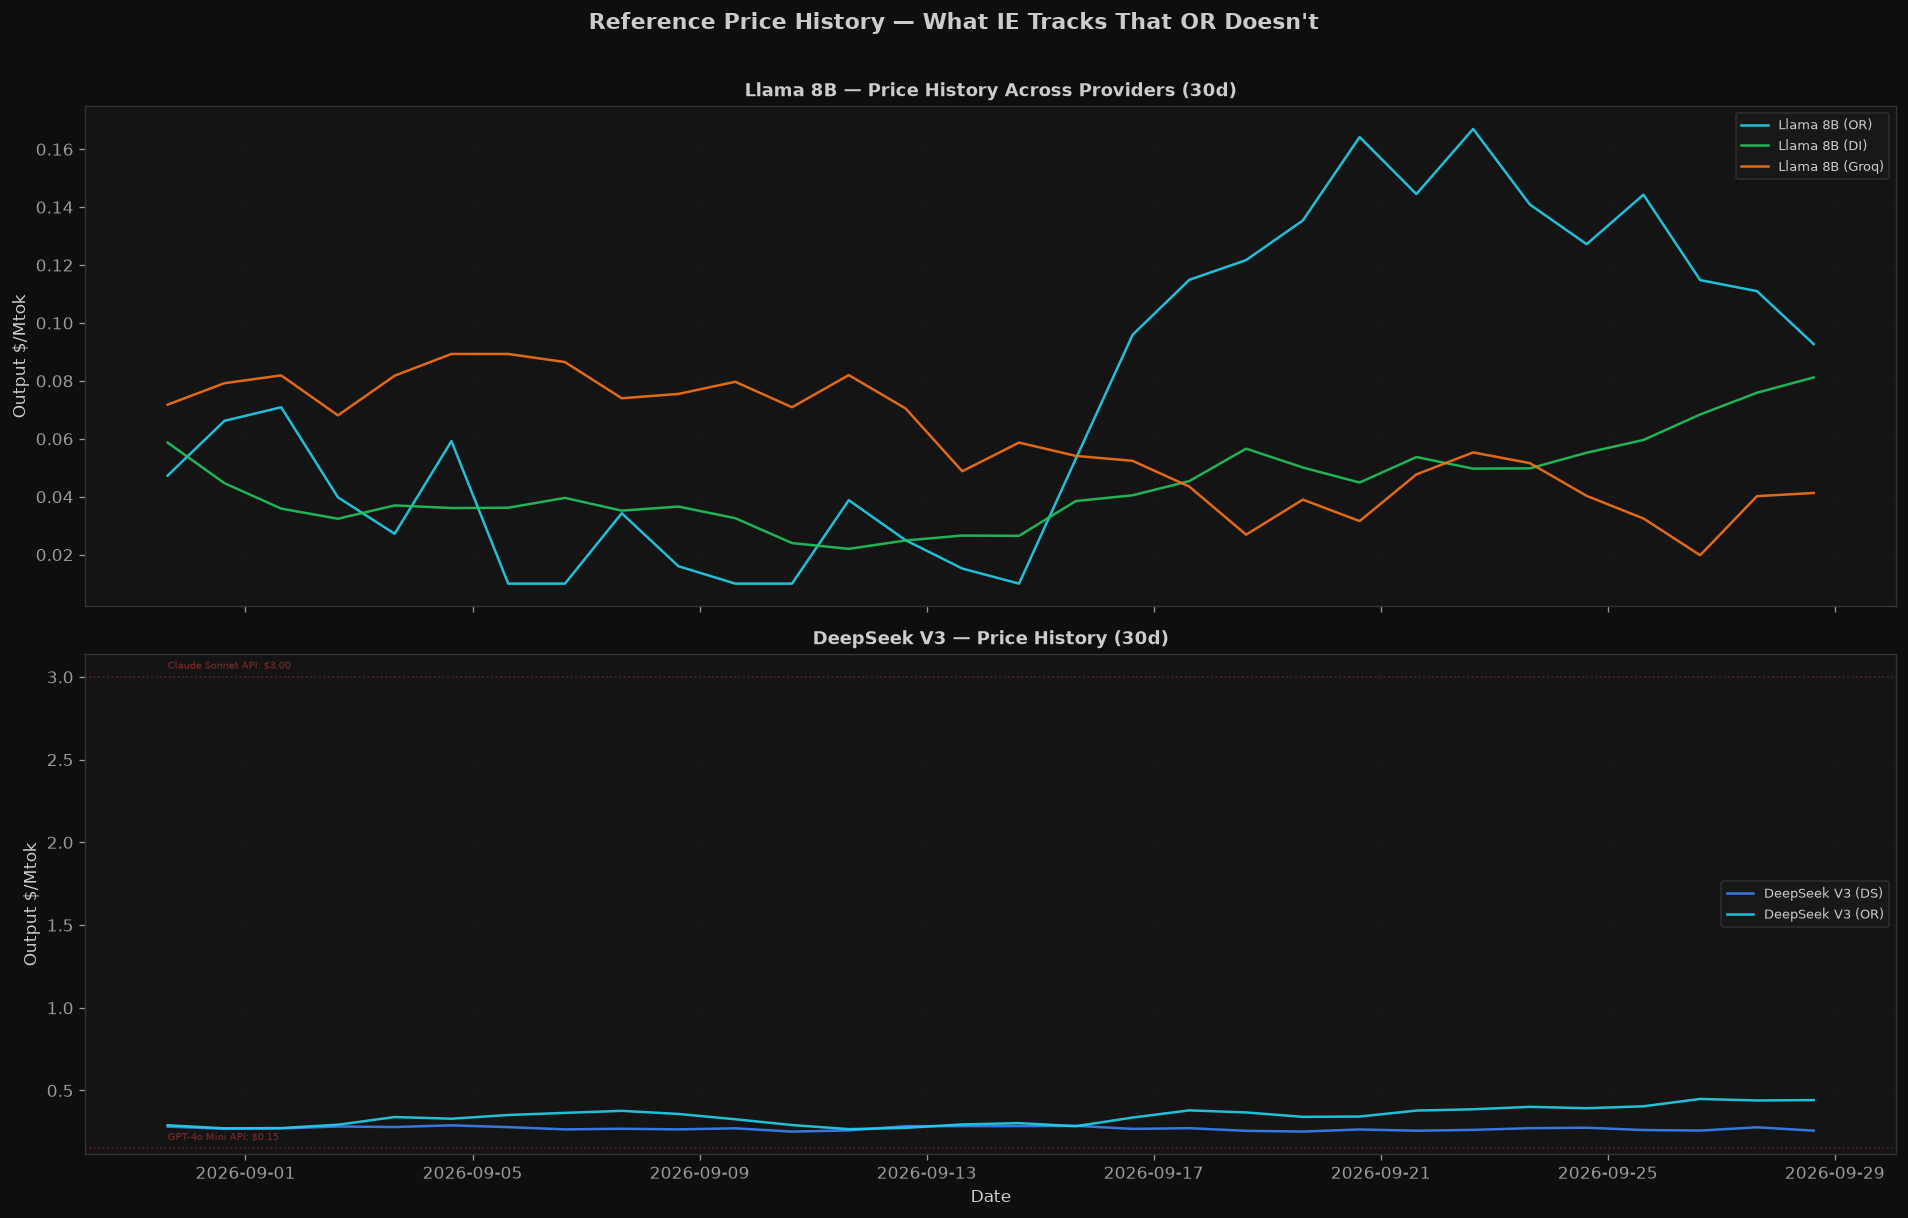

In [7]:
# Simulate 30-day price history for key models
days = 30
dates = [datetime.now() - timedelta(days=days-i) for i in range(days)]

# Each model has a base price and a drift/volatility profile
price_histories = {
    "Llama 8B (OR)":      {"base": 0.07, "vol": 0.02, "trend": -0.001},  # slowly getting cheaper
    "Llama 8B (DI)":      {"base": 0.06, "vol": 0.005, "trend": 0},      # stable
    "Llama 8B (Groq)":    {"base": 0.08, "vol": 0.01, "trend": -0.0005},
    "DeepSeek V3 (DS)":   {"base": 0.27, "vol": 0.01, "trend": 0},
    "DeepSeek V3 (OR)":   {"base": 0.30, "vol": 0.03, "trend": -0.002},
    "Claude Sonnet (API)": {"base": 3.00, "vol": 0.0, "trend": 0},       # fixed API price
    "GPT-4o Mini (API)":  {"base": 0.15, "vol": 0.0, "trend": 0},
}

np.random.seed(123)
history_data = []
for model, params in price_histories.items():
    price = params["base"]
    for i, date in enumerate(dates):
        price = max(0.01, price + params["trend"] + np.random.normal(0, params["vol"]))
        history_data.append({"model": model, "date": date, "output_price": round(price, 4)})

hist_df = pd.DataFrame(history_data)

# Plot: Llama 8B across providers
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Llama 8B
for model in ["Llama 8B (OR)", "Llama 8B (DI)", "Llama 8B (Groq)"]:
    sub = hist_df[hist_df["model"] == model]
    color = {"OR": C_CYAN, "DI": C_GREEN, "Groq": C_ORANGE}
    c = [v for k, v in color.items() if k in model][0]
    ax1.plot(sub["date"], sub["output_price"], linewidth=1.5, alpha=0.9, color=c, label=model)

ax1.set_ylabel("Output $/Mtok")
ax1.set_title("Llama 8B — Price History Across Providers (30d)", fontsize=11, fontweight="bold")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# DeepSeek V3
for model in ["DeepSeek V3 (DS)", "DeepSeek V3 (OR)"]:
    sub = hist_df[hist_df["model"] == model]
    c = C_BLUE if "DS" in model else C_CYAN
    ax2.plot(sub["date"], sub["output_price"], linewidth=1.5, alpha=0.9, color=c, label=model)

# Overlay fixed API prices for reference
ax2.axhline(3.00, color=C_RED, linestyle=":", alpha=0.3, linewidth=1)
ax2.text(dates[0], 3.05, "Claude Sonnet API: $3.00", fontsize=6, color=C_RED, alpha=0.5)
ax2.axhline(0.15, color=C_RED, linestyle=":", alpha=0.3, linewidth=1)
ax2.text(dates[0], 0.20, "GPT-4o Mini API: $0.15", fontsize=6, color=C_RED, alpha=0.5)

ax2.set_ylabel("Output $/Mtok")
ax2.set_xlabel("Date")
ax2.set_title("DeepSeek V3 — Price History (30d)", fontsize=11, fontweight="bold")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

fig.suptitle("Reference Price History — What IE Tracks That OR Doesn't",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 7 — Cache hit rate analysis: the demand-side edge

IE tracks `cached_tokens` per request (from the transaction schema).  This lets
us show consumers their actual cache hit rate and how it affects their costs —
a metric no other inference marketplace exposes.


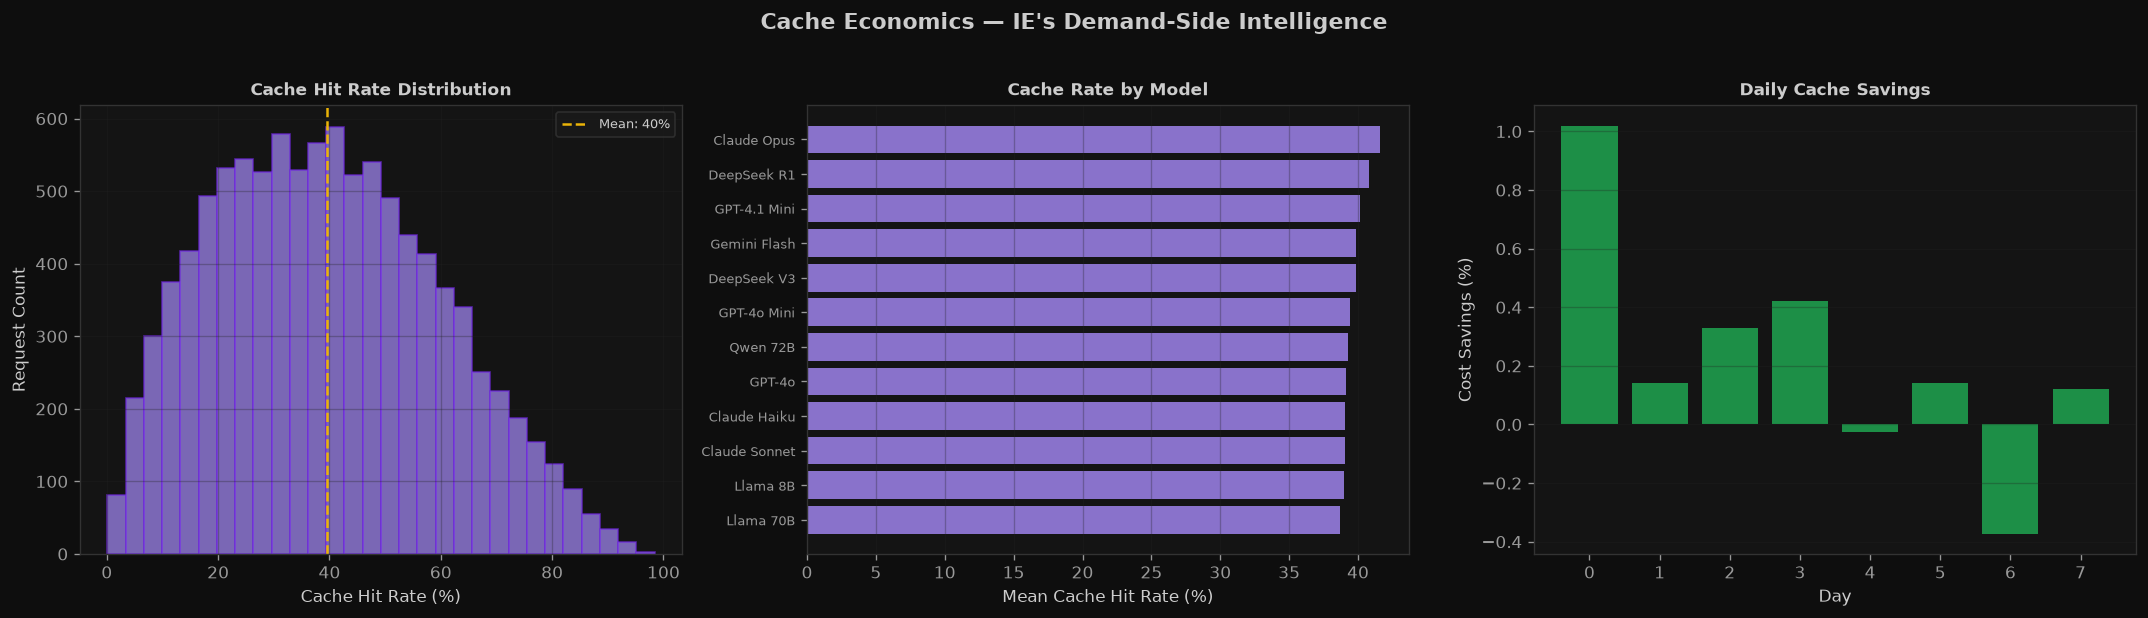

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cache hit rate distribution
ax = axes[0]
ax.hist(sim_df["cache_rate"] * 100, bins=30, color=C_PURPLE, alpha=0.7, edgecolor="#6d28d9")
ax.set_xlabel("Cache Hit Rate (%)")
ax.set_ylabel("Request Count")
ax.set_title("Cache Hit Rate Distribution", fontsize=10, fontweight="bold")
ax.axvline(sim_df["cache_rate"].mean() * 100, color=C_GOLD, linestyle="--",
           label=f"Mean: {sim_df['cache_rate'].mean():.0%}")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Cache hit rate by model
ax = axes[1]
model_cache = sim_df.groupby("model")["cache_rate"].mean().sort_values(ascending=False)
ax.barh(range(len(model_cache)), model_cache.values * 100, color=C_PURPLE, alpha=0.8)
ax.set_yticks(range(len(model_cache)))
ax.set_yticklabels(model_cache.index, fontsize=8)
ax.set_xlabel("Mean Cache Hit Rate (%)")
ax.set_title("Cache Rate by Model", fontsize=10, fontweight="bold")
ax.grid(True, axis="x", alpha=0.3)
ax.invert_yaxis()

# Savings from caching (estimated)
ax = axes[2]
sim_df["fresh_input_tokens"] = sim_df["input_tokens"] - sim_df["cached_tokens"]
sim_df["no_cache_cost"] = sim_df["input_tokens"] / 1e6 * sim_df["output_price"] * 0.3 + sim_df["output_tokens"] / 1e6 * sim_df["output_price"]
sim_df["with_cache_cost"] = sim_df["cost_usd"]
daily_savings = sim_df.groupby("day").agg(
    no_cache=("no_cache_cost", "sum"),
    with_cache=("cost_usd", "sum"),
).reset_index()
daily_savings["savings"] = daily_savings["no_cache"] - daily_savings["with_cache"]
daily_savings["savings_pct"] = (daily_savings["savings"] / daily_savings["no_cache"] * 100)

ax.bar(range(len(daily_savings)), daily_savings["savings_pct"], color=C_GREEN, alpha=0.7)
ax.set_xlabel("Day")
ax.set_ylabel("Cost Savings (%)")
ax.set_title("Daily Cache Savings", fontsize=10, fontweight="bold")
ax.grid(True, axis="y", alpha=0.3)
ax.set_xticks(range(0, len(daily_savings), max(1, len(daily_savings)//7)))

fig.suptitle("Cache Economics — IE's Demand-Side Intelligence",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 8 — Exchange dashboard: putting it all together

This is what the IE Exchange page data layer looks like — combining supply (DOM),
demand (volume profile), pricing dimensions (three-tier), and market intelligence
(cache economics, price history).

### What IE shows that OR doesn't:

| Dimension | OpenRouter | Inference Exchange |
|-----------|-----------|-------------------|
| Pricing | Single output price | Input / Cache / Output (three-tier) |
| Cache economics | Not exposed | Cache hit rate, savings per request |
| Trust level | Not exposed | L0 open → L3 confidential |
| Encryption | Not exposed | E2E encryption status per provider |
| Offer book | Hidden (provider routing opaque) | Full DOM — every provider's offer visible |
| Price history | Not available | 30/90 day trend per model per source |
| Volume profile | Not available | Demand concentration by price level |
| TPS tracking | Not available | Per-provider measured throughput (EMA) |
| Latency/TTFT | Not available | Per-request latency, time-to-first-token |
| Provider hardware | Not available | Hardware class per provider |
| Capacity/load | Not available | Active requests / max concurrent |

These are the dimensions that turn IE from a "cheaper OpenRouter" into an actual
inference marketplace.


In [9]:
# Summary stats
print("=" * 65)
print("EXCHANGE ANALYTICS SUMMARY")
print("=" * 65)
print()
print("SUPPLY SIDE (live OpenRouter + static providers)")
print(f"  Models with pricing:         {len(or_df)}")
print(f"  Vendors:                     {or_df['vendor'].nunique()}")
print(f"  Direct-API reference prices: {len(tier_df)}")
print(f"  Models with three-tier data: {len(tier_df[tier_df['cache'] > 0])}")
print()
print("DEMAND SIDE (simulated)")
print(f"  Requests (7d):              {len(sim_df):,}")
print(f"  Output tokens:              {sim_df['output_tokens'].sum():,}")
print(f"  Input tokens:               {sim_df['input_tokens'].sum():,}")
print(f"  Mean cache hit rate:        {sim_df['cache_rate'].mean():.1%}")
print(f"  Median latency:             {sim_df['latency_ms'].median():.0f} ms")
print(f"  Median TPS:                 {sim_df['tps'].median():.0f} tok/s")
print()
print("IE DIFFERENTIATORS")
print("  ✓ Three-tier pricing (input/cache/output)")
print("  ✓ Cache hit rate tracking and savings computation")
print("  ✓ Provider-level offer book (DOM)")
print("  ✓ Reference price history (30/90 day)")
print("  ✓ Trust level as a pricing dimension")
print("  ✓ E2E encryption status")
print("  ✓ Per-provider TPS (EMA-tracked)")
print("  ✓ Latency + TTFT per request")
print("  ✓ Hardware class visibility")
print("  ✓ Capacity/load factor")
print("=" * 65)


EXCHANGE ANALYTICS SUMMARY

SUPPLY SIDE (live OpenRouter + static providers)
  Models with pricing:         438
  Vendors:                     52
  Direct-API reference prices: 16
  Models with three-tier data: 11

DEMAND SIDE (simulated)
  Requests (7d):              10,000
  Output tokens:              4,981,959
  Input tokens:               10,895,211
  Mean cache hit rate:        39.6%
  Median latency:             1114 ms
  Median TPS:                 80 tok/s

IE DIFFERENTIATORS
  ✓ Three-tier pricing (input/cache/output)
  ✓ Cache hit rate tracking and savings computation
  ✓ Provider-level offer book (DOM)
  ✓ Reference price history (30/90 day)
  ✓ Trust level as a pricing dimension
  ✓ E2E encryption status
  ✓ Per-provider TPS (EMA-tracked)
  ✓ Latency + TTFT per request
  ✓ Hardware class visibility
  ✓ Capacity/load factor
